In [9]:
import pandas as pd

df = pd.read_csv("kc_house_data.csv")

# First look
display(df.head())
display(df.tail())

# Shape
print(df.shape)

# Column names
print(df.columns)

# Dataset information
df.info()

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

# Duplicate rows
print(df.duplicated().sum())

# Statistical summary
display(df.describe())

# Correlation of every numeric feature with price
df.corr(numeric_only=True)["price"].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


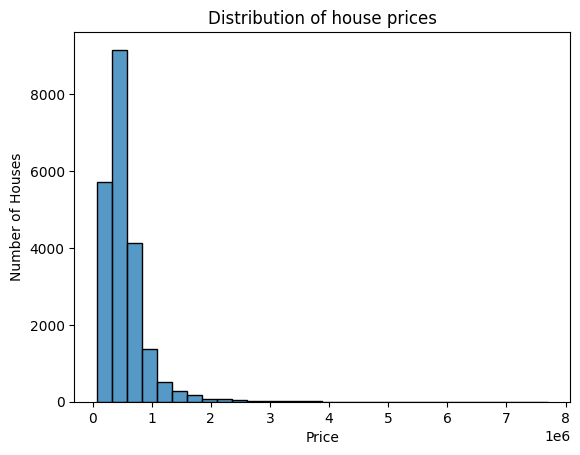

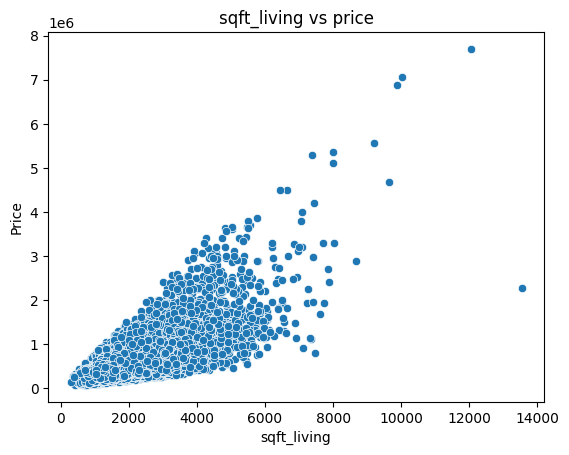

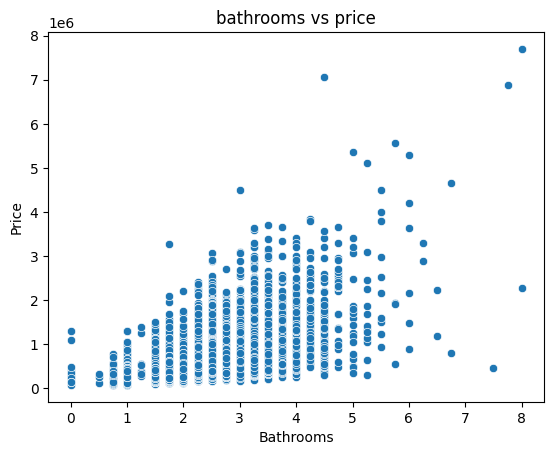

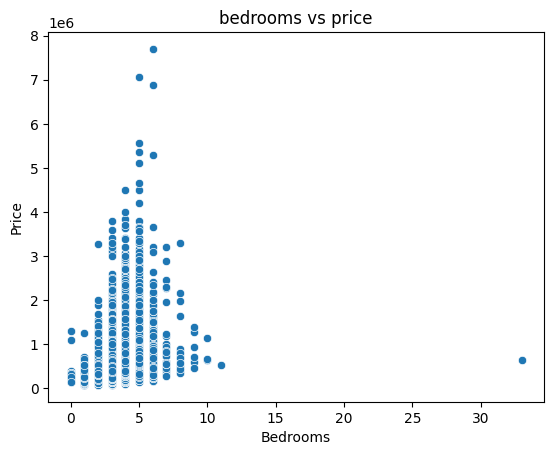

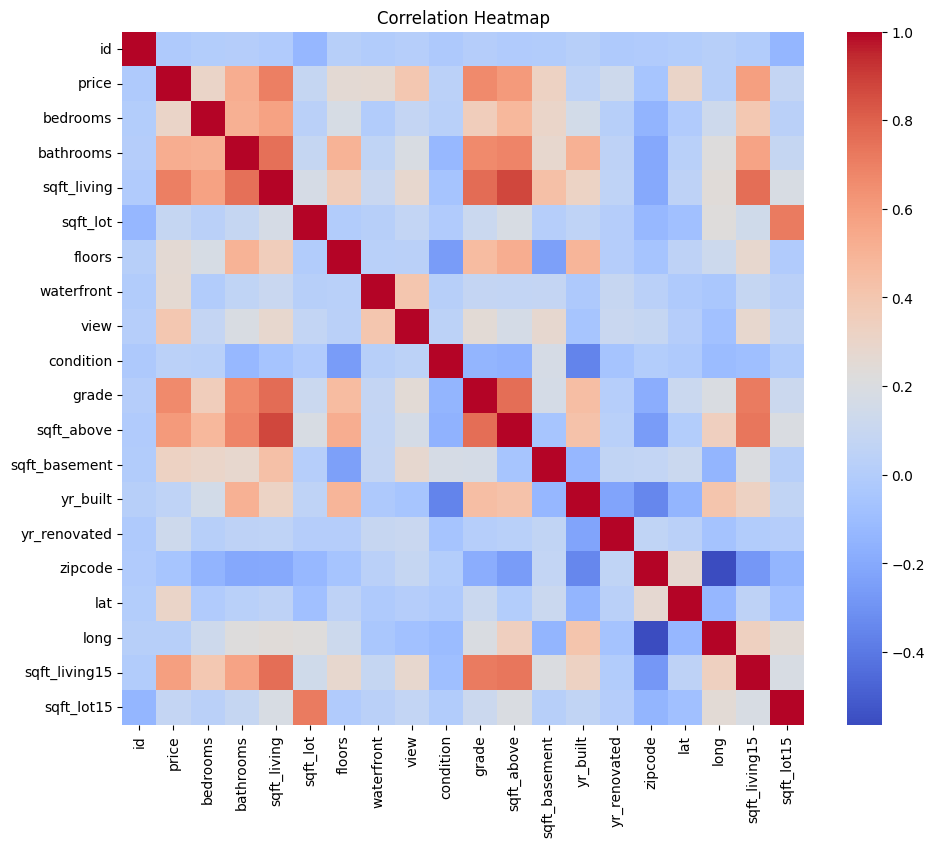

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of house prices
sns.histplot(df['price'], bins=30)
plt.title("Distribution of house prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

# 2. Scatter plot:
# sqft_living vs price
sns.scatterplot(x=df['sqft_living'],y=df['price'])
plt.title("sqft_living vs price")
plt.xlabel("sqft_living")
plt.ylabel("Price")
plt.show()

# bathrooms vs price
sns.scatterplot(x=df['bathrooms'],y=df['price'])
plt.title("bathrooms vs price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

# bedrooms vs price
sns.scatterplot(x=df['bedrooms'],y=df['price'])
plt.title("bedrooms vs price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(11,9))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y = df["price"]
X = df[["bedrooms", "bathrooms", "sqft_living", "grade", "view", "condition"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train,y_train)

predictions= model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² :", r2)


MAE : 156751.00535506537
MSE: 61468612277.54657
RMSE: 247928.64351975665
R² : 0.5933989345322683
